In [2]:
import pandas as pd
import numpy as np

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import os
import joblib

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv(
    "../data/processed/customer_support_en.csv"
)

df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8,text_length
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN,544
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN,534
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN,605
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN,677
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,high,en,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN,646


In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing.pipeline import preprocess_text

In [6]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/customer_support_en.csv"
)

print(df.columns.tolist())

['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8', 'text_length']


In [7]:
df["combined_text"] = (
    df["subject"].fillna("").astype(str)
    + " "
    + df["body"].fillna("").astype(str)
)

df[
    [
        "subject",
        "body",
        "combined_text",
        "type"
    ]
].head()

,subject,body,combined_text,type
0,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,...",Incident
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...,Request
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...,Request
3,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...,Problem
4,Feature Query,"Dear Customer Support,\n\nI hope this message ...","Feature Query Dear Customer Support,\n\nI hope...",Request


In [8]:
df["processed_text"] = (
    df["combined_text"]
    .fillna("")
    .astype(str)
    .apply(preprocess_text)
)

In [9]:
df[
[
"processed_text",
"type"
]
].head()

,processed_text,type
0,account disruption dear customer support team ...,Incident
1,query smart home system integration feature de...,Request
2,inquiry regarding invoice detail dear customer...,Request
3,question marketing agency software compatibili...,Problem
4,feature query dear customer support n ni hope ...,Request


In [10]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["type"]
)

df[
[
"type",
"label"
]
].head()

,type,label
0,Incident,1
1,Request,3
2,Request,3
3,Problem,2
4,Request,3


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df["processed_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [12]:
vocab_size = 10000
max_length = 100


tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)


tokenizer.fit_on_texts(
    X_train
)

In [13]:
X_train_seq = tokenizer.texts_to_sequences(
    X_train
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)

In [14]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post"
)


X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post"
)

In [15]:
model = Sequential()


model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)


model.add(
    Bidirectional(
        LSTM(
            64
        )
    )
)


model.add(
    Dropout(
        0.5
    )
)


model.add(
    Dense(
        64,
        activation="relu"
    )
)


model.add(
    Dense(
        len(label_encoder.classes_),
        activation="softmax"
    )
)


model.summary()

d:\NLP_Group_35\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [17]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.7243 - loss: 0.5835 - val_accuracy: 0.8087 - val_loss: 0.4098
Epoch 2/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 37s 113ms/step - accuracy: 0.8107 - loss: 0.3793 - val_accuracy: 0.8263 - val_loss: 0.3630
Epoch 3/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 46s 128ms/step - accuracy: 0.8498 - loss: 0.3157 - val_accuracy: 0.8336 - val_loss: 0.3467
Epoch 4/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.8834 - loss: 0.2699 - val_accuracy: 0.8439 - val_loss: 0.3372
Epoch 5/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - accuracy: 0.9068 - loss: 0.2309 - val_accuracy: 0.8416 - val_loss: 0.3577
Epoch 6/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9174 - loss: 0.2057 - val_accuracy: 0.8466 - val_loss: 0.3815
Epoch 7/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 35s 107ms/step - accuracy: 0.9353 - loss: 0.1670 - val_accuracy: 0.8412 - val_loss: 0.4416
Epoch 8/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9448 - loss: 0

In [18]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print(
    "BiLSTM Accuracy:",
    accuracy
)

103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8553 - loss: 0.4622
BiLSTM Accuracy: 0.8552631735801697


In [19]:
pred_probs = model.predict(
    X_test_pad
)

predictions = np.argmax(
    pred_probs,
    axis=1
)

103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step


In [20]:
print(
classification_report(
    y_test,
    predictions,
    target_names=label_encoder.classes_
)
)

              precision    recall  f1-score   support

      Change       0.98      0.97      0.98       341
    Incident       0.79      0.88      0.84      1314
     Problem       0.71      0.56      0.63       680
     Request       0.99      0.99      0.99       933

    accuracy                           0.86      3268
   macro avg       0.87      0.85      0.86      3268
weighted avg       0.85      0.86      0.85      3268



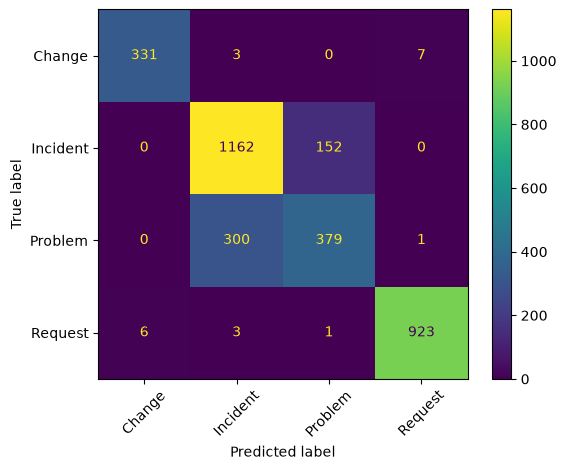

In [21]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.show()

In [22]:
os.makedirs(
    "../src/models/member1",
    exist_ok=True
)


model.save(
    "../src/models/member1/bilstm_model.keras"
)

In [23]:
joblib.dump(
    tokenizer,
    "../src/models/member1/tokenizer.pkl"
)


joblib.dump(
    label_encoder,
    "../src/models/member1/label_encoder.pkl"
)

['../src/models/member1/label_encoder.pkl']